###  Titanic Dataset - Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to analyze the Titanic dataset, perform data cleaning, handle missing values, visualize important features, and derive meaningful business insights using Python.

# 1. Import Libraries

In [65]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

The Titanic dataset is loaded from Seaborn's built-in datasets for performing exploratory data analysis.

In [2]:
df=sns.load_dataset("titanic")

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 3. Data Understanding

Before cleaning the dataset, we first examine its structure, dimensions, summary statistics and missing values.

In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df.shape

(891, 15)

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# 4. Missing Value Handling

The Age column contains missing values.

Before selecting an imputation technique, we check the distribution and skewness of the data.

In [8]:
df["age"].skew()

np.float64(0.38910778230082704)

## Question

Is the Age column normally distributed?

### Why Histogram?

A histogram is used to visualize the distribution of a continuous numerical variable.

Text(0.5, 1.0, 'DISTRIBUTION OF AGE')

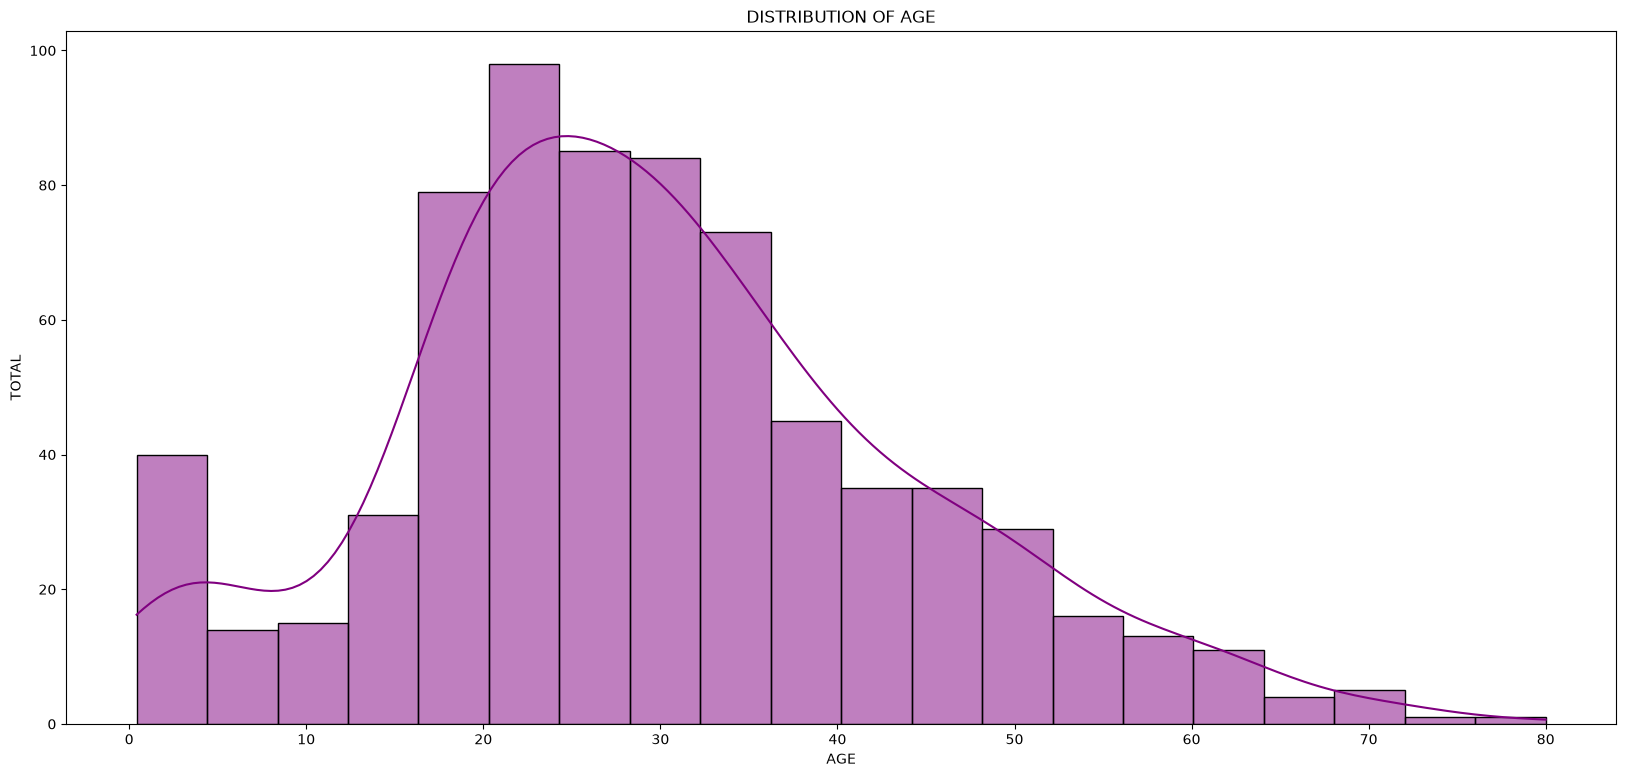

In [9]:
### Histogram 

plt.figure(figsize = (20,9))

sns.histplot(df["age"],kde = True,color="purple",edgecolor="black")
plt.xlabel("AGE")
plt.ylabel("TOTAL")
plt.title("DISTRIBUTION OF AGE")

###  Question

Does the Age column contain outliers?

### Why Boxplot?

A boxplot helps identify outliers and understand data spread.

<Axes: ylabel='age'>

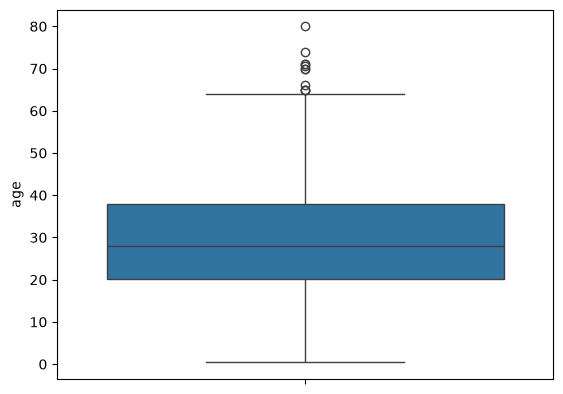

In [10]:
sns.boxplot(df["age"])

### Observation

The Age column is approximately normally distributed with only a few outliers.

Therefore, the missing values were imputed using the mean.

In [11]:
df["age"]=df["age"].fillna(df["age"].mean())
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Handling Missing Values in the `deck` Column

The `deck` column contains **688 missing values** out of **891** records, which means approximately **77%** of the data is missing.

Since such a large portion of the column is unavailable, imputing the missing values using the mode would not be reliable and could introduce significant bias into the analysis.

Therefore, the `deck` column is removed from the dataset.

In [13]:
df.drop("deck",axis=1,inplace=True)

### Handling Missing Values in `embarked` and `embark_town`

Both columns contain only **2 missing values**.

Since these are categorical variables and the number of missing values is very small, the missing entries are imputed using the **mode** (most frequent category).

In [14]:
df["embark_town"].mode()
df["embarked"].mode()

0    S
Name: embarked, dtype: str

In [15]:
df["embark_town"]=df["embark_town"].fillna(df["embark_town"].mode()[0])
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [16]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### Observation

All missing values have now been handled successfully.

The dataset is clean and ready for exploratory data analysis.

# 5. Univariate Analysis

Univariate analysis examines one variable at a time to understand its distribution and characteristics.

## Question

How many male and female passengers are present in the dataset?

### Why Countplot?

Countplots are ideal for displaying the frequency of categorical variables.

<Axes: xlabel='sex', ylabel='count'>

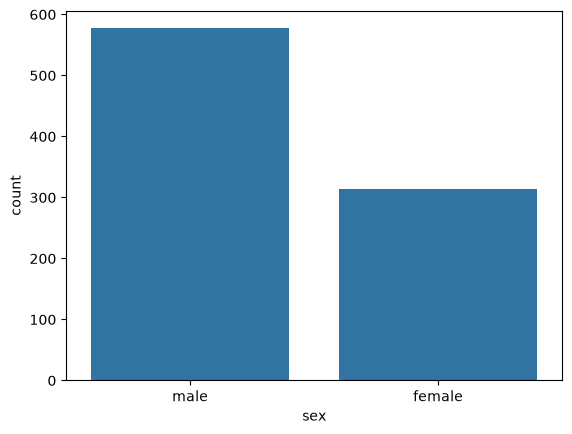

In [17]:
## TOTAL  

sns.countplot(x="sex", data=df)

## Question

How many passengers survived?

### Why Countplot?

A countplot provides an easy comparison between survivors and non-survivors.

<Axes: xlabel='survived', ylabel='count'>

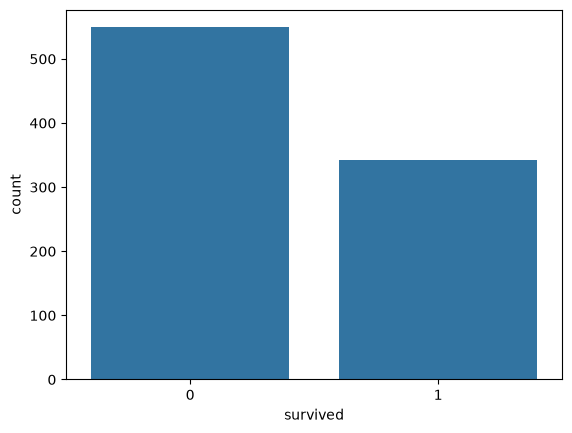

In [18]:
sns.countplot(x="survived", data=df)

# 6. Bivariate Analysis

Bivariate analysis explores the relationship between two variables.

In [19]:
survived = df.groupby("sex")["survived"].sum().reset_index()
survived

,sex,survived
0,female,233
1,male,109


##  Question

Did gender influence passenger survival?

### Why Bar Plot?

A bar plot is used to compare the number of survivors across different gender categories.

Text(0.5, 1.0, 'TOTAL SURVIVED')

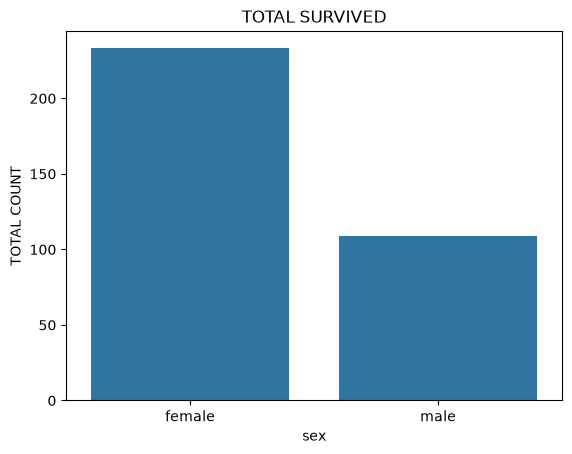

In [20]:
# BAR PLOT OF SURVIVE

sns.barplot(x="sex", y="survived", data=survived)
plt.xlabel("sex")
plt.ylabel("TOTAL COUNT")
plt.title("TOTAL SURVIVED")

### Observation

Female passengers had a significantly higher number of survivors than male passengers.

##  Question

Which passenger class had the highest number of survivors?

In [21]:
### Groupby Passenger class survived
 
passenger_class_survived=df.groupby("class")["survived"].sum().reset_index()

passenger_class_survived


,class,survived
0,First,136
1,Second,87
2,Third,119


<Axes: xlabel='class', ylabel='survived'>

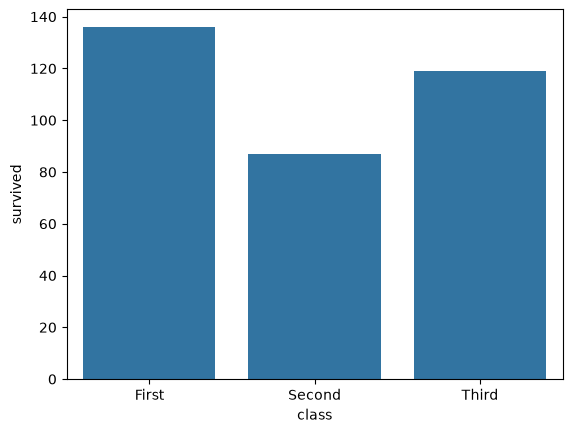

In [22]:
sns.barplot(x="class",y="survived",data=passenger_class_survived)

## Question

What is the age distribution of passengers?

### Why Histogram?

A histogram helps visualize the distribution of a continuous numerical variable.

Text(0.5, 1.0, 'DISTRIBUTION OF AGE')

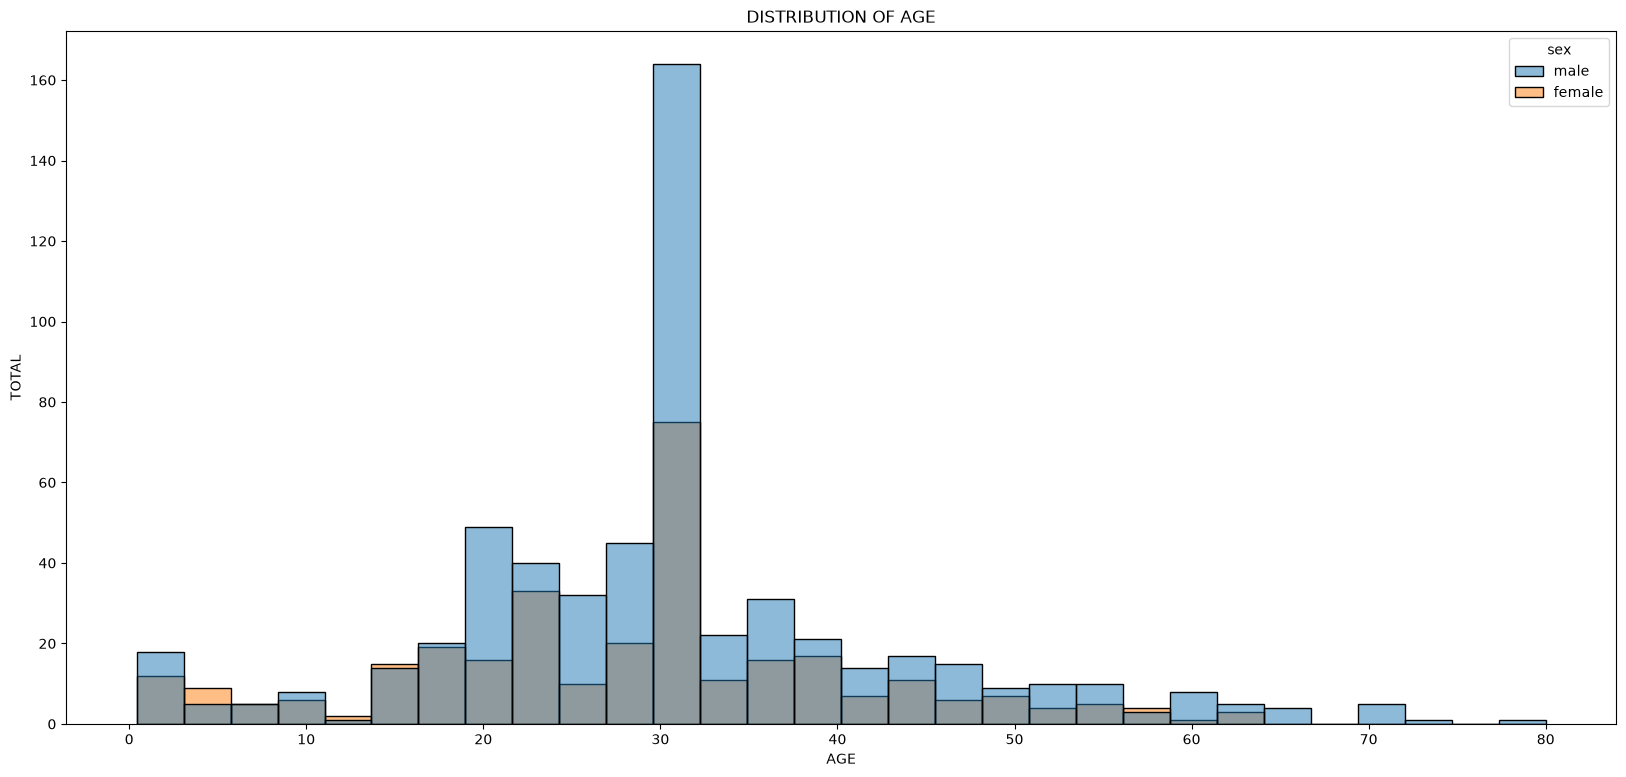

In [23]:
### Histogram


plt.figure(figsize = (20,9))

sns.histplot(data=df,x="age",hue="sex",edgecolor="black")
plt.xlabel("AGE")
plt.ylabel("TOTAL")
plt.title("DISTRIBUTION OF AGE")

#### Is there a relationship between Age and Fare?

<Axes: xlabel='age', ylabel='fare'>

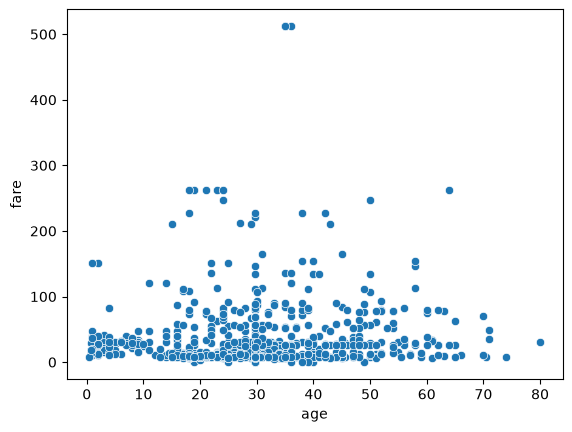

In [24]:
### Scatter plot

sns.scatterplot(x="age",y="fare",data=df)

In [25]:
##3 HEAT MAP

corr=df[["age","fare"]].corr()
corr

,age,fare
age,1.000000,0.091566
fare,0.091566,1.000000


<Axes: >

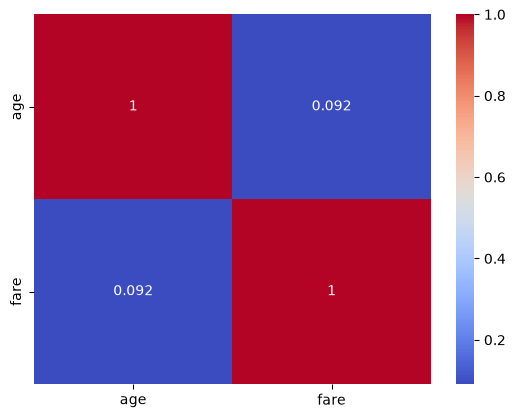

In [26]:
sns.heatmap(corr,annot=True,cmap="coolwarm")

##  Question

Did the embarkation port influence passenger survival?

### Methodology

Since each embarkation port has a different number of passengers, comparing survival rates (%) provides a fairer analysis than comparing survivor counts.

In [41]:
port =df.groupby("embark_town")["survived"].sum().reset_index()

port = port.rename(columns={"survived": "survivors"})

port

,embark_town,survivors
0,Cherbourg,93
1,Queenstown,30
2,Southampton,219


In [43]:
total =df.groupby("embark_town")["survived"].count().reset_index()
total = total.rename(columns={"survived": "total_passengers"})
total

,embark_town,total_passengers
0,Cherbourg,168
1,Queenstown,77
2,Southampton,646


In [44]:
Port_survived=pd.merge(total,port,on="embark_town",how="inner")
Port_survived

,embark_town,total_passengers,survivors
0,Cherbourg,168,93
1,Queenstown,77,30
2,Southampton,646,219


### Finding Survival rate 


In [46]:
Port_survived["survival_rate"] = (Port_survived["survivors"] / Port_survived["total_passengers"]) * 100
Port_survived

,embark_town,total_passengers,survivors,survival_rate
0,Cherbourg,168,93,55.357143
1,Queenstown,77,30,38.961039
2,Southampton,646,219,33.900929


Text(0.5, 1.0, 'Survival rate of each embarked')

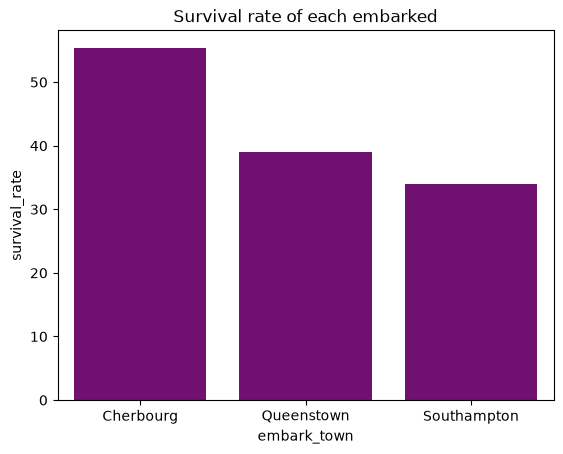

In [49]:
### BAR PLOT

sns.barplot(x="embark_town",y="survival_rate",data=Port_survived,color="purple")
plt.title("Survival rate of each embarked")

### Observation

Passengers boarding at Cherbourg had the highest survival rate.

Southampton had the lowest survival rate.

This indicates that embarkation port may have influenced passenger survival.

#### Did family size affect passenger survival?

In [54]:
df["Family_Size"]=df["parch"]+df["sibsp"]+1


## Feature Engineering

A new feature called `Family_Size` is created using:

This helps analyze whether travelling alone or with family influenced survival.

In [58]:
family_size=df.groupby("Family_Size")["survived"].mean().reset_index()
family_size
family_size = family_size.rename(columns={"survived": "survival_rate"})
family_size

,Family_Size,survival_rate
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [63]:
df["Family_Size"].value_counts().sort_index()

Family_Size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

<Axes: xlabel='Family_Size', ylabel='survival_rate'>

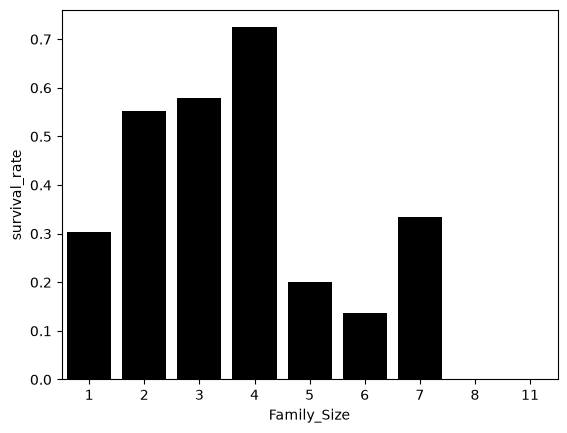

In [62]:
### BAR PLOT 
sns.barplot(x="Family_Size",y="survival_rate",data=family_size,color="black")

### Observation

Passengers travelling with families of 2–4 members generally had higher survival rates than passengers travelling alone.

Survival rates decreased for larger families.

However, conclusions for family sizes 8 and 11 should be interpreted cautiously because these groups contain very few passengers.

# 7. Conclusion

## Key Findings

- Missing values in the Age column were imputed using the mean after analyzing the distribution.
- The Deck column was removed because approximately 77% of its values were missing.
- Missing values in Embarked and Embark Town were filled using the mode.
- Female passengers had a higher survival count than male passengers.
- First-class passengers had the highest number of survivors.
- Cherbourg recorded the highest passenger survival rate.
- Small families (2–4 members) generally had better survival rates than passengers travelling alone.
- Age and Fare showed only a weak positive correlation.

## Overall Summary

This exploratory data analysis identified several factors associated with passenger survival, including gender, passenger class, embarkation port, and family size. The project also demonstrated essential data analysis techniques such as data cleaning, feature engineering, aggregation, and visualization using Python.